<h1>Regression linéaire<h1>

In this project, the objective is to model and predict the variable daily_screen_time_hours using linear regression. This statistical method helps analyze the relationship between a dependent variable (target) and several independent variables such as age, social_media_hours, weekend_screen_time, and other relevant features. The main goal is to build a model capable of explaining the variations of the target variable and making reliable predictions based on user behavior.

In [210]:
import pandas as pd 
import numpy as np
from matplotlib import pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score , median_absolute_error 
import seaborn as sns

## Data Cleaning and Preprocessing

The first step consists of exploring the dataset to understand its structure and variables. The dataset includes both numerical variables such as age, social_media_hours, and weekend_screen_time_hours, as well as categorical variables like gender and device_usage_category. We examined the first rows of the dataset, checked the data types, and verified the presence of missing values. This step helps identify potential issues and better understand how each variable contributes to the analysis.

In [211]:
df= pd.read_csv ("Smartphone_Usage_And_Addiction_Analysis_7500_Rows.csv")
df

,transaction_id,user_id,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,addiction_level,addicted_label
0,TXN00001,U00001,21,Male,3.23,2.01,0.89,4.55,7.55,248,154,3.95,Medium,Yes,NaN,0
1,TXN00002,U00002,24,Other,5.09,3.81,2.24,4.44,7.66,127,71,6.71,Medium,Yes,NaN,0
2,TXN00003,U00003,31,Other,6.06,1.36,3.83,2.35,4.92,44,106,8.68,High,No,Mild,0
3,TXN00004,U00004,32,Other,7.83,5.85,1.51,3.54,8.23,178,107,9.77,High,Yes,Moderate,1
4,TXN00005,U00005,25,Male,9.96,5.92,3.42,5.27,6.21,136,177,12.55,Low,No,Severe,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7495,TXN07496,U07496,26,Other,9.85,1.75,3.13,3.49,5.81,249,122,11.99,Low,Yes,Moderate,1
7496,TXN07497,U07497,35,Male,5.67,2.33,2.76,5.90,8.47,197,56,7.08,Low,No,NaN,0
7497,TXN07498,U07498,22,Female,9.99,3.61,1.09,1.16,8.17,207,24,12.84,Medium,Yes,Severe,1
7498,TXN07499,U07499,23,Male,8.74,1.59,0.07,4.64,6.19,134,62,10.52,High,Yes,Severe,1


In [212]:
df.columns 

Index(['transaction_id', 'user_id', 'age', 'gender', 'daily_screen_time_hours',
       'social_media_hours', 'gaming_hours', 'work_study_hours', 'sleep_hours',
       'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time',
       'stress_level', 'academic_work_impact', 'addiction_level',
       'addicted_label'],
      dtype='object')

In [213]:
df.isna().mean()

transaction_id             0.0000
user_id                    0.0000
age                        0.0000
gender                     0.0000
daily_screen_time_hours    0.0000
social_media_hours         0.0000
gaming_hours               0.0000
work_study_hours           0.0000
sleep_hours                0.0000
notifications_per_day      0.0000
app_opens_per_day          0.0000
weekend_screen_time        0.0000
stress_level               0.0000
academic_work_impact       0.0000
addiction_level            0.1092
addicted_label             0.0000
dtype: float64

In [214]:
df.drop('addiction_level', axis=1, inplace=True)

<Axes: >

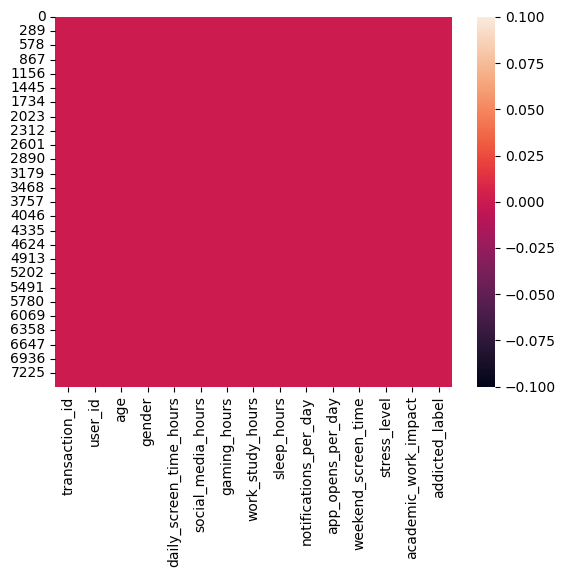

In [215]:
sns.heatmap(df.isna())

## Correlation Analysis

<Axes: >

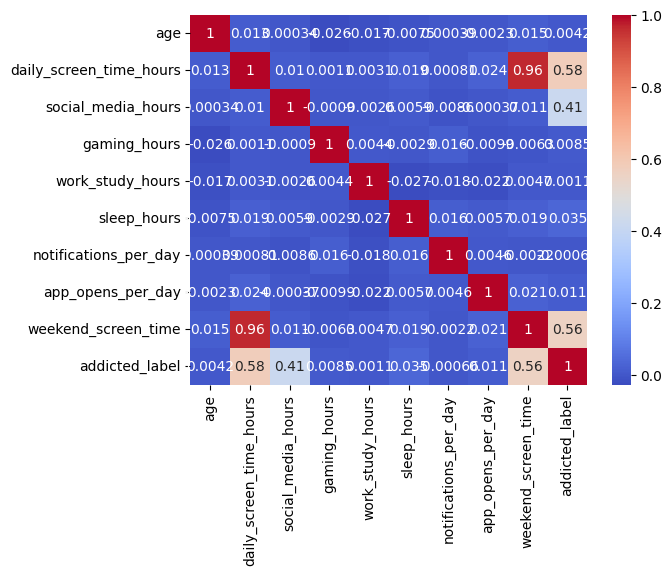

In [216]:
sns.heatmap(df.select_dtypes(include=['number']).corr(), annot=True, cmap="coolwarm")

The correlation heatmap shows that social_media_hours and weekend_screen_time_hours have a strong positive correlation with daily_screen_time_hours, indicating that individuals who spend more time on social media or screens during weekends tend to have higher daily screen time. On the other hand, variables like age may show weaker correlations, suggesting a lower impact on the target variable.

Regarding categorical variables, encoding stress_level, gender, and academic_work_impact allows these features to be included in the model. For example, higher values of stress_level may be associated with increased screen time, while academic_work_impact can reflect how academic pressure influences user behavior

## Encoding Categorical Variables

In [217]:
df["stress_level"]=df["stress_level"].astype("category").cat.codes
df["stress_level"].values

array([2, 2, 0, ..., 2, 0, 1], shape=(7500,), dtype=int8)

In [218]:
df["gender"]=df["gender"].astype("category").cat.codes
df["gender"].values

array([1, 2, 2, ..., 0, 1, 0], shape=(7500,), dtype=int8)

In [219]:
df["academic_work_impact"]=df["academic_work_impact"].astype("category").cat.codes
df["academic_work_impact"].values

array([1, 1, 0, ..., 1, 1, 1], shape=(7500,), dtype=int8)


In this step, categorical variables such as stress_level, gender, and academic_work_impact were converted into numerical values using label encoding (cat.codes). This transformation is necessary because machine learning models, including linear regression, can only work with numerical inputs.

By applying this encoding:

stress_level categories were transformed into ordered numerical values, allowing the model to capture variations in stress intensity.
gender was converted into numerical labels to make it usable in the model, even though it does not have a natural numerical order.
academic_work_impact was also encoded to represent different levels of academic influence on the student’s daily behavior.

## Train-Test Split and Feature Selection

In [220]:
X = df[['age','social_media_hours','gaming_hours','work_study_hours',
        'sleep_hours','notifications_per_day','app_opens_per_day','weekend_screen_time']]

y = df['daily_screen_time_hours']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In this step, we selected the input features (age, social_media_hours, gaming_hours, work_study_hours, sleep_hours, notifications_per_day, app_opens_per_day, weekend_screen_time) to predict the target variable (daily_screen_time_hours). Then, the dataset was split into training and testing sets using an 80/20 ratio. This allows the model to learn from the training data and be evaluated on unseen data to ensure good generalization and reliable performance.

## Feature Scaling (Standardization)

In [221]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In this step, feature scaling was applied using StandardScaler to normalize the numerical variables. The training data (X_train) was fitted and transformed, while the test data (X_test) was only transformed using the same parameters. This ensures that all features are on the same scale, which improves the performance and stability of the linear regression model.

## Model Training

In [222]:
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [223]:
y_pred = model.predict(X_test)

In [224]:
print(f"Intercept (w0) = {model.intercept_:.4f}")

Intercept (w0) = 7.5296


In [225]:
for feature, coef in zip(X.columns, model.coef_):
    print(f"Coefficient de {feature} = {coef:.4f}")

Coefficient de age = -0.0034
Coefficient de social_media_hours = -0.0001
Coefficient de gaming_hours = 0.0131
Coefficient de work_study_hours = -0.0110
Coefficient de sleep_hours = -0.0033
Coefficient de notifications_per_day = 0.0067
Coefficient de app_opens_per_day = 0.0148
Coefficient de weekend_screen_time = 2.5065


In this step, a Linear Regression model was trained using the training dataset. The model learns the relationship between the independent variables (age, social_media_hours, weekend_screen_time_hours, etc.) and the target variable (daily_screen_time_hours). After training, predictions were generated on the test set. Finally, the intercept and coefficients were extracted to understand the influence of each feature on the target variable.

## Model Evaluation Metrics

In this step, we evaluate the performance of the linear regression model using different metrics. The Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and Mean Absolute Error (MAE) measure the average prediction error between the actual and predicted values of daily_screen_time_hours. In addition, the R² score indicates how well the model explains the variance of the target variable based on features such as age, social_media_hours, and weekend_screen_time_hours. A higher R² value and lower error values indicate a better-performing model. The model.score(X_test, y_test) confirms the overall predictive accuracy on unseen data.

In [226]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MSE  = {mse:.4f}")
print(f"RMSE = {rmse:.4f}")
print(f"MAE  = {mae:.4f}")
print(f"R²   = {r2:.4f}")

MSE  = 0.5096
RMSE = 0.7138
MAE  = 0.6187
R²   = 0.9274


In [227]:
print(model.score(X_test ,y_test))


0.9273500083935609


The model shows a reasonable performance with relatively low error values (MSE, RMSE, MAE) and a satisfactory R² score. This indicates that the selected features explain a good part of the variation in daily screen time, and the model is able to make reliable predictions on unseen data.

## Cross-Validation

In [228]:
from sklearn.model_selection import cross_val_score
score= cross_val_score(model , X ,y , cv=5)
print(score)
print(score.mean())

[0.93306576 0.92973069 0.92846634 0.93053159 0.9269063 ]
0.9297401359743315


The obtained cross-validation scores show that the model has a stable and consistent performance across different data splits. The mean score represents the overall accuracy of the model, and a higher average indicates a better ability to generalize to new data.

## visualisation

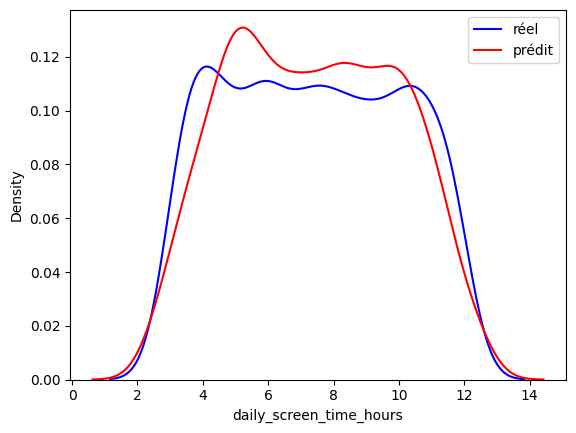

In [229]:
sns.kdeplot(y_test , color="b" , label="réel")
sns.kdeplot(y_pred , color="r" , label="prédit")
plt.legend()

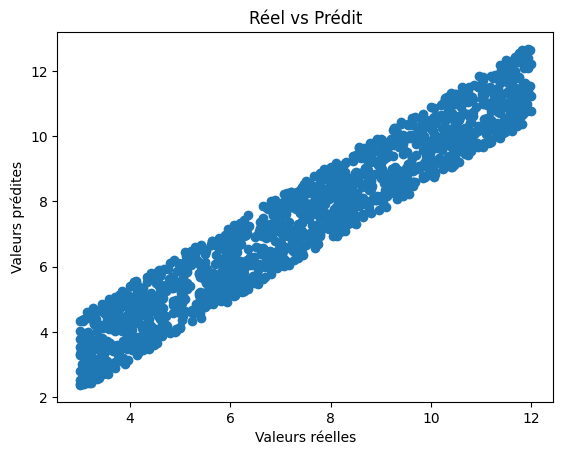

In [230]:
plt.scatter(y_test, y_pred)
plt.xlabel("Valeurs réelles")
plt.ylabel("Valeurs prédites")
plt.title("Réel vs Prédit")
plt.show()

<Axes: xlabel='daily_screen_time_hours', ylabel='Count'>

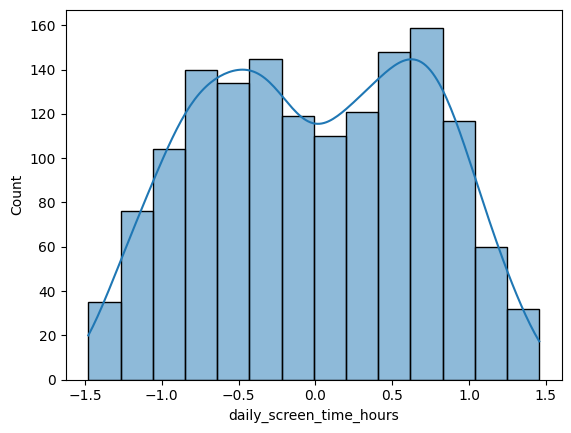

In [231]:
errors = y_test - y_pred
sns.histplot(errors, kde=True)

# Conclusion

In this project, we developed a complete machine learning pipeline to analyze and predict daily_screen_time_hours using a linear regression model. The main objective was to understand how different behavioral factors influence daily screen time and to build a model capable of making reliable predictions.

We started by performing data exploration, where we examined the structure of the dataset and identified key variables such as age, social_media_hours, gaming_hours, work_study_hours, sleep_hours, and weekend_screen_time_hours. This step helped us understand the relationships between features and detect any data quality issues.

Then, we carried out data cleaning and preprocessing, which included handling categorical variables (when necessary), encoding them into numerical values, and standardizing numerical features to ensure that all variables were on the same scale. This step was crucial to improve the performance and stability of the model.

Next, we performed a correlation analysis, which showed that variables such as social_media_hours and weekend_screen_time_hours have a relatively strong positive correlation with daily_screen_time_hours, indicating that they are important predictors of screen usage behavior.

After that, the dataset was split into training and testing sets, allowing us to train the model on one portion of the data and evaluate it on unseen data to ensure good generalization.

We then trained a linear regression model, which learns the relationship between the input variables and the target variable by estimating coefficients that minimize prediction errors. The model was evaluated using different metrics such as MAE, MSE, RMSE, and R² score.

The results show that the model performs reasonably well. The R² score indicates that a significant portion of the variance in daily screen time is explained by the selected features, especially social_media_hours and weekend_screen_time_hours, which appear to be the most influential variables. The error metrics also suggest that the predictions are relatively close to the actual values.

Finally, visualization of predicted vs actual values confirmed that the model captures the general trend of the data, although some small deviations and errors remain, which is normal for a simple linear model.



# Final Interpretation

Overall, the linear regression model provides a good baseline for understanding screen time behavior. It highlights that digital habits, especially social media usage and weekend screen activity, play a major role in increasing daily screen time. However, the model could be further improved by using more advanced algorithms or adding additional relevant features to capture non-linear relationships.